In [20]:
import numpy as np

labels = np.array([0,1,2,3,4,5,6,7,8])
train_filepath = "my_data/standard1/train.csv"
test_filepath  = "my_data/standard1/test.csv"
EPS = 1e-8

train_data = np.loadtxt(train_filepath, delimiter=",", skiprows=1)
test_data  = np.loadtxt(test_filepath,  delimiter=",", skiprows=1)

train_X, train_y = train_data[:, :-1], train_data[:, -1].astype(int)
test_X,  test_y  = test_data[:, :-1],  test_data[:, -1].astype(int)

num_labels = len(labels)
num_features = train_X.shape[1]

print(f"Train samples: {len(train_X)}")
print(f"Test samples : {len(test_X)}")
print(f"Features     : {num_features}")
print(f"Labels       : {labels}")

train_medians = np.zeros((num_labels, num_features))
train_std     = np.zeros((num_labels, num_features))

for i, lbl in enumerate(labels):
    X_lbl = train_X[train_y == lbl]

    train_medians[i] = np.median(X_lbl, axis=0)
    train_std[i]     = np.std(X_lbl, axis=0, ddof=1)

# Avoid divide-by-zero
train_std[train_std < EPS] = EPS

def get_zscores(features, medians, stds):
    # features [...1344]
    # medians & stds [[...1344], ...9]
    # returns: zscores [[...1344], ...9]
    return (features - medians) / stds

def abs_zscores(zscores):
    # zscore [[...1344], ...9]
    return abs(zscores)

def get_labels_scores(zscores):
    # zscore [[...1344], ...9]
    # returns: labels_scores [...9]
    # Note: lower score is better (means closer to model)
    R = 1
    return np.sum(zscores, axis=R)

def get_pred_labels(labels_scores):
    # labels_score [...9]
    # returns: pred_labels [...9] of labels with label at spot 0 being the SMALLEST label score, and so on
    pred_label_indices = np.argsort(labels_scores) #yes I do want the smallest at index 0
    pred_labels = labels[pred_label_indices]
    return pred_labels

def is_accurate(pred_labels, label, max_checks=len(labels)):
    # pred_labels [...9]
    # label int
    # max_trys int
    # check if pre_label at idx=0 matches label, if not and max_trys allows it, try again, ...
    for check in range(max_checks):
        if pred_labels[check] == label: return True, check
    return False, max_checks
    
all_pred_labels = []
accuracy_struct = []
for i in range(len(test_y)):
    zscores = get_zscores(test_X[i], train_medians, train_std)
    zscores = abs_zscores(zscores)
    labels_scores = get_labels_scores(zscores)
    pred_labels = get_pred_labels(labels_scores)
    all_pred_labels.append(pred_labels)
    accuracy_struct.append(is_accurate(pred_labels, test_y[i]))
    if i % 10 == 0: print(f"{i} Pred: {pred_labels}, Label: {test_y[i]}, {is_accurate(pred_labels, test_y[i])}")

# showcase the outputs for this. show a confusion matrix with all (True, 0) and show a confusion matrix with all (True,0) and (True, 1) 

acc_totals = [0, 0, 0, 0, 0, 0, 0, 0, 0]
for acc in accuracy_struct:
    is_acc, order = acc
    if is_acc: acc_totals[order] +=1

print(np.array(acc_totals) / len(test_y) * 100) 
        
    


Train samples: 12915
Test samples : 3296
Features     : 1344
Labels       : [0 1 2 3 4 5 6 7 8]
0 Pred: [8 2 7 1 6 5 4 0 3], Label: 8, (True, 0)
10 Pred: [0 4 3 5 6 1 2 7 8], Label: 3, (True, 2)
20 Pred: [5 6 4 1 2 0 3 7 8], Label: 5, (True, 0)
30 Pred: [2 1 6 7 5 4 0 8 3], Label: 7, (True, 3)
40 Pred: [0 3 4 5 1 6 2 7 8], Label: 0, (True, 0)
50 Pred: [6 5 4 1 0 2 3 7 8], Label: 5, (True, 1)
60 Pred: [0 4 3 5 6 1 2 7 8], Label: 0, (True, 0)
70 Pred: [0 4 3 6 5 1 2 7 8], Label: 0, (True, 0)
80 Pred: [5 6 4 1 0 3 2 7 8], Label: 5, (True, 0)
90 Pred: [0 6 4 5 1 3 2 7 8], Label: 0, (True, 0)
100 Pred: [8 2 7 1 6 5 4 0 3], Label: 2, (True, 1)
110 Pred: [2 1 7 6 8 5 4 0 3], Label: 2, (True, 0)
120 Pred: [2 1 8 7 6 5 4 0 3], Label: 2, (True, 0)
130 Pred: [1 2 4 6 5 0 3 7 8], Label: 1, (True, 0)
140 Pred: [2 1 7 6 5 4 8 0 3], Label: 2, (True, 0)
150 Pred: [0 4 3 5 6 1 2 7 8], Label: 0, (True, 0)
160 Pred: [1 2 4 6 0 5 3 7 8], Label: 2, (True, 1)
170 Pred: [2 1 6 7 5 4 8 0 3], Label: 2, (True, 

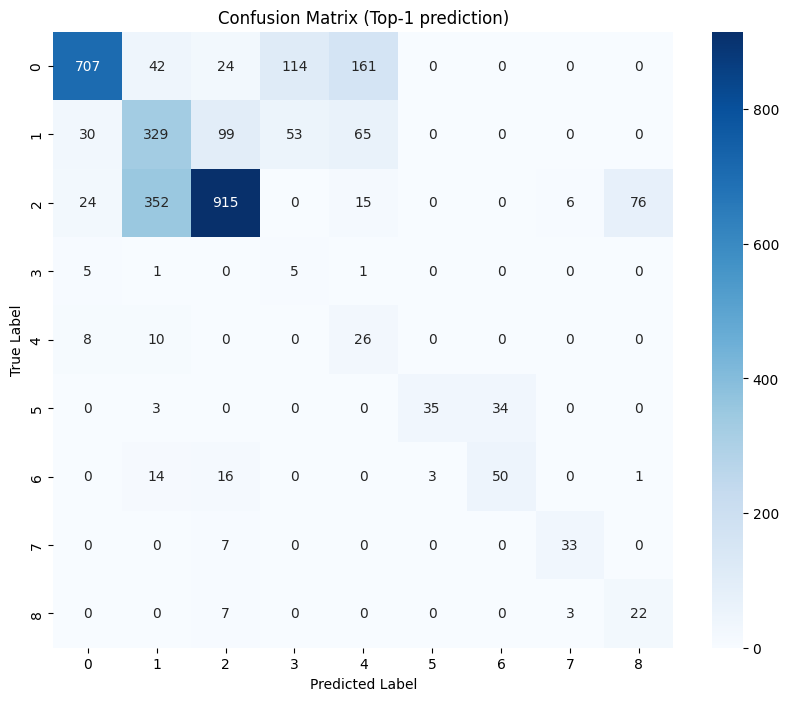

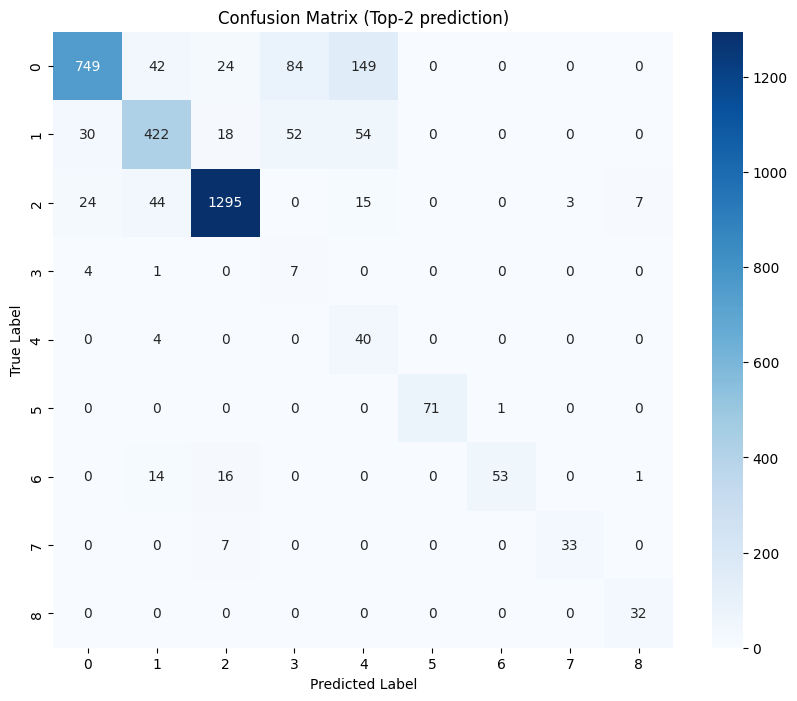

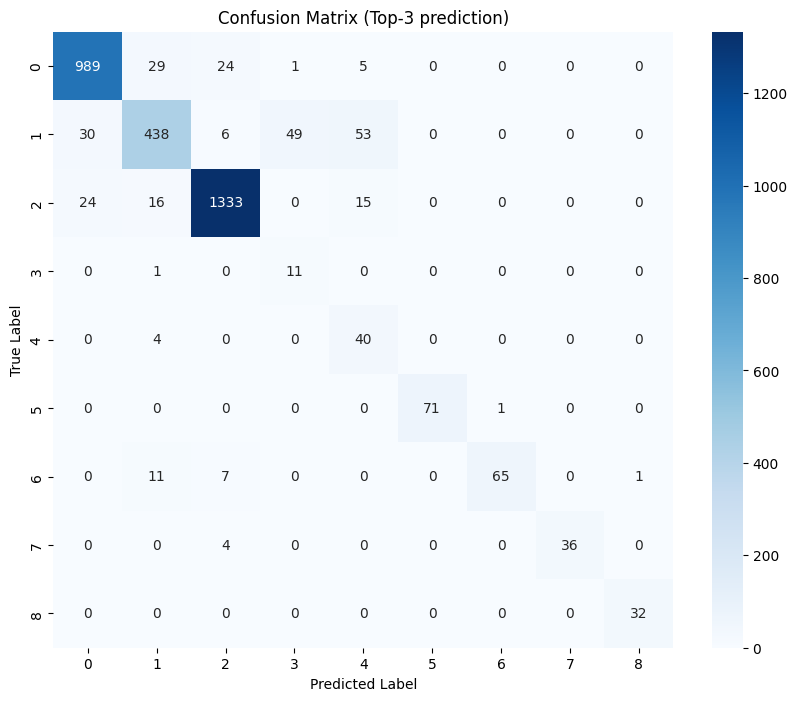

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

#I apologize

# Initialize confusion matrices
conf_mat_top1 = np.zeros((num_labels, num_labels), dtype=int)  # only top-1 prediction
conf_mat_top2 = np.zeros((num_labels, num_labels), dtype=int)  # top-1 or top-2 prediction
conf_mat_top3 = np.zeros((num_labels, num_labels), dtype=int)  # top-1, top-2, or top-3 prediction

for i, (pred_labels, (is_acc, order)) in enumerate(zip(all_pred_labels, accuracy_struct)):
    true_label = test_y[i]
    true_idx = np.where(labels == true_label)[0][0]

    pred_label_top1 = pred_labels[0]
    pred_idx_top1 = np.where(labels == pred_label_top1)[0][0]
    conf_mat_top1[true_idx, pred_idx_top1] += 1

    # Top-2 confusion matrix
    if is_acc and order <= 1:
        pred_label_top2 = pred_labels[order]
        pred_idx_top2 = np.where(labels == pred_label_top2)[0][0]
        conf_mat_top2[true_idx, pred_idx_top2] += 1
    else:
        conf_mat_top2[true_idx, pred_idx_top1] += 1

    # Top-3 confusion matrix
    if is_acc and order <= 2:
        pred_label_top3 = pred_labels[order]
        pred_idx_top3 = np.where(labels == pred_label_top3)[0][0]
        conf_mat_top3[true_idx, pred_idx_top3] += 1
    else:
        conf_mat_top3[true_idx, pred_idx_top1] += 1


# Plot confusion matrices nicely
def plot_confusion_matrix(conf_mat, title):
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_mat, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(title)
    plt.show()

plot_confusion_matrix(conf_mat_top1, "Confusion Matrix (Top-1 prediction)")
plot_confusion_matrix(conf_mat_top2, "Confusion Matrix (Top-2 prediction)")
plot_confusion_matrix(conf_mat_top3, "Confusion Matrix (Top-3 prediction)")

Train samples: 12915
Test samples : 3296
Features     : 1536
Labels       : [0 1 2 3 4 5 6 7 8]
0 Pred: [2 8 7 1 6 5 4 0 3], Label: 8, (True, 1)
10 Pred: [0 4 3 5 1 6 2 7 8], Label: 3, (True, 2)
20 Pred: [5 6 4 1 2 0 3 7 8], Label: 5, (True, 0)
30 Pred: [2 1 7 6 5 4 0 8 3], Label: 7, (True, 2)
40 Pred: [0 3 4 1 5 6 2 7 8], Label: 0, (True, 0)
50 Pred: [6 5 4 1 3 2 0 7 8], Label: 5, (True, 1)
60 Pred: [0 4 3 1 5 6 2 7 8], Label: 0, (True, 0)
70 Pred: [0 4 3 6 5 1 2 7 8], Label: 0, (True, 0)
80 Pred: [5 6 4 1 0 3 2 7 8], Label: 5, (True, 0)
90 Pred: [0 4 6 5 1 3 2 7 8], Label: 0, (True, 0)
100 Pred: [8 2 7 1 6 5 4 0 3], Label: 2, (True, 1)
110 Pred: [2 1 7 6 8 5 4 0 3], Label: 2, (True, 0)
120 Pred: [2 1 8 7 6 5 4 0 3], Label: 2, (True, 0)
130 Pred: [1 2 6 4 5 0 3 7 8], Label: 1, (True, 0)
140 Pred: [2 1 7 6 5 4 8 0 3], Label: 2, (True, 0)
150 Pred: [0 4 3 1 5 6 2 7 8], Label: 0, (True, 0)
160 Pred: [1 2 4 6 5 0 3 7 8], Label: 2, (True, 1)
170 Pred: [2 1 6 5 7 4 8 0 3], Label: 2, (True, 

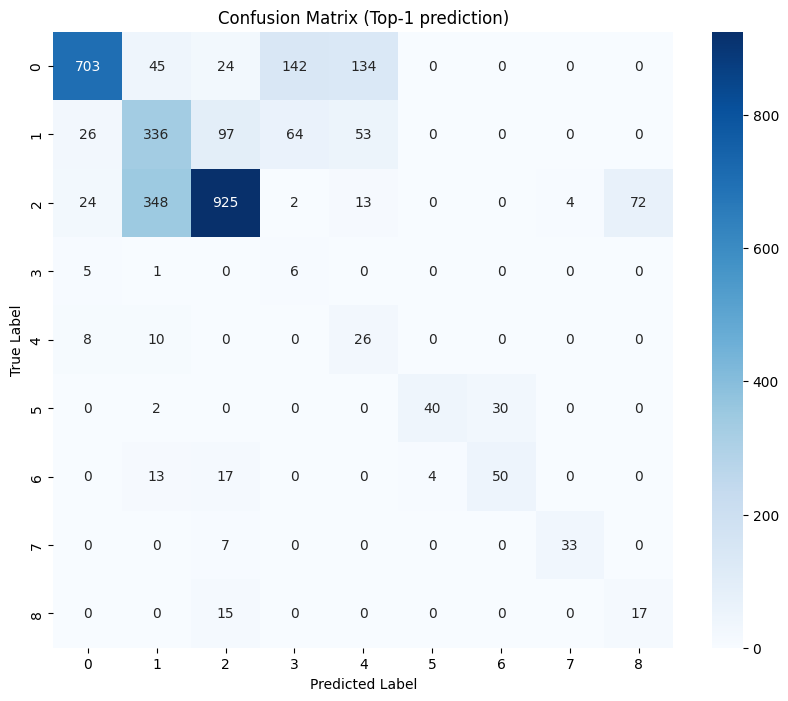

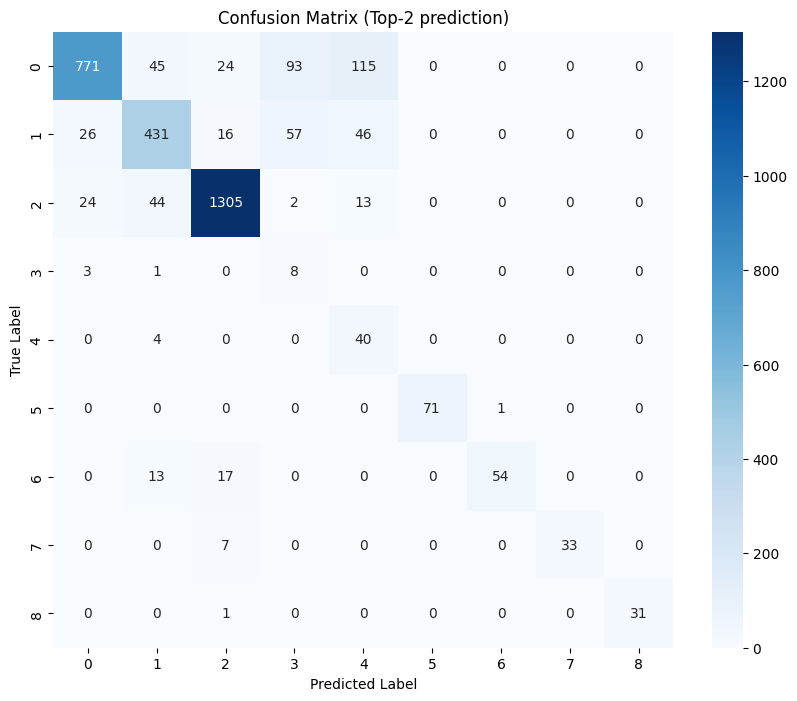

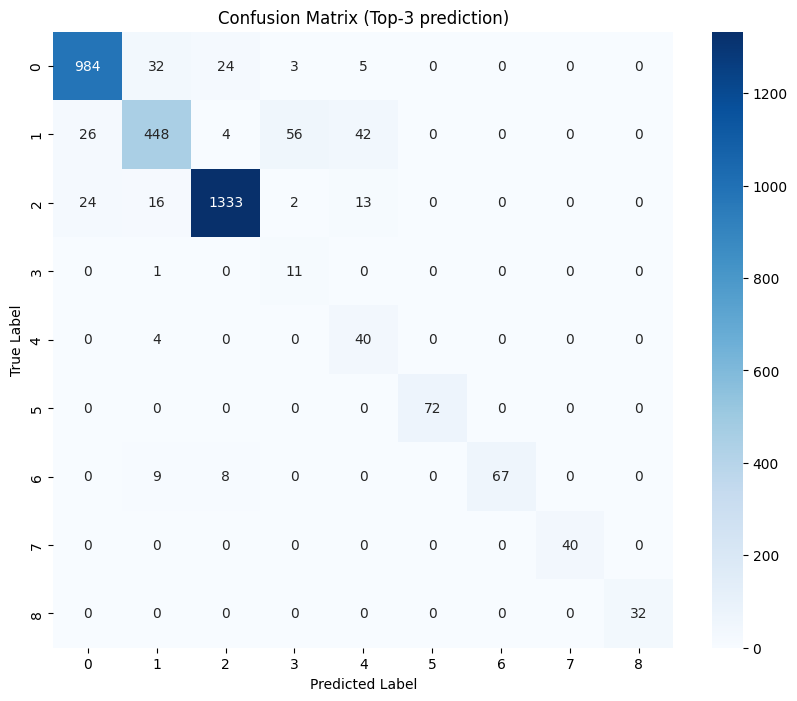

In [25]:
## using different data

import numpy as np

labels = np.array([0,1,2,3,4,5,6,7,8])
train_filepath = "my_data/standard2/train.csv"
test_filepath  = "my_data/standard2/test.csv"
EPS = 1e-8

train_data = np.loadtxt(train_filepath, delimiter=",", skiprows=1)
test_data  = np.loadtxt(test_filepath,  delimiter=",", skiprows=1)

train_X, train_y = train_data[:, :-1], train_data[:, -1].astype(int)
test_X,  test_y  = test_data[:, :-1],  test_data[:, -1].astype(int)

num_labels = len(labels)
num_features = train_X.shape[1]

print(f"Train samples: {len(train_X)}")
print(f"Test samples : {len(test_X)}")
print(f"Features     : {num_features}")
print(f"Labels       : {labels}")

train_medians = np.zeros((num_labels, num_features))
train_std     = np.zeros((num_labels, num_features))

for i, lbl in enumerate(labels):
    X_lbl = train_X[train_y == lbl]

    train_medians[i] = np.median(X_lbl, axis=0)
    train_std[i]     = np.std(X_lbl, axis=0, ddof=1)

# Avoid divide-by-zero
train_std[train_std < EPS] = EPS

def get_zscores(features, medians, stds):
    # features [...1344]
    # medians & stds [[...1344], ...9]
    # returns: zscores [[...1344], ...9]
    return (features - medians) / stds

def abs_zscores(zscores):
    # zscore [[...1344], ...9]
    return abs(zscores)

def get_labels_scores(zscores):
    # zscore [[...1344], ...9]
    # returns: labels_scores [...9]
    # Note: lower score is better (means closer to model)
    R = 1
    return np.sum(zscores, axis=R)

def get_pred_labels(labels_scores):
    # labels_score [...9]
    # returns: pred_labels [...9] of labels with label at spot 0 being the smallest label score, and so on
    pred_label_indices = np.argsort(labels_scores)
    pred_labels = labels[pred_label_indices]
    return pred_labels

def is_accurate(pred_labels, label, max_checks=len(labels)):
    # pred_labels [...9]
    # label int
    # max_trys int
    # check if pre_label at idx=0 matches label, if not and max_trys allows it, try again, ...
    for check in range(max_checks):
        if pred_labels[check] == label: return True, check
    return False, max_checks
    
all_pred_labels = []
accuracy_struct = []
for i in range(len(test_y)):
    zscores = get_zscores(test_X[i], train_medians, train_std)
    zscores = abs_zscores(zscores)
    labels_scores = get_labels_scores(zscores)
    pred_labels = get_pred_labels(labels_scores)
    all_pred_labels.append(pred_labels)
    accuracy_struct.append(is_accurate(pred_labels, test_y[i]))
    if i % 10 == 0: print(f"{i} Pred: {pred_labels}, Label: {test_y[i]}, {is_accurate(pred_labels, test_y[i])}")

# showcase the outputs for this. show a confusion matrix with all (True, 0) and show a confusion matrix with all (True,0) and (True, 1) 

acc_totals = [0, 0, 0, 0, 0, 0, 0, 0, 0]
for acc in accuracy_struct:
    is_acc, order = acc
    if is_acc: acc_totals[order] +=1

print(np.array(acc_totals) / len(test_y) * 100) 


import matplotlib.pyplot as plt
import seaborn as sns

#I apologize

# Initialize confusion matrices
conf_mat_top1 = np.zeros((num_labels, num_labels), dtype=int)  # only top-1 prediction
conf_mat_top2 = np.zeros((num_labels, num_labels), dtype=int)  # top-1 or top-2 prediction
conf_mat_top3 = np.zeros((num_labels, num_labels), dtype=int)  # top-1, top-2, or top-3 prediction

for i, (pred_labels, (is_acc, order)) in enumerate(zip(all_pred_labels, accuracy_struct)):
    true_label = test_y[i]
    true_idx = np.where(labels == true_label)[0][0]

    pred_label_top1 = pred_labels[0]
    pred_idx_top1 = np.where(labels == pred_label_top1)[0][0]
    conf_mat_top1[true_idx, pred_idx_top1] += 1

    # Top-2 confusion matrix
    if is_acc and order <= 1:
        pred_label_top2 = pred_labels[order]
        pred_idx_top2 = np.where(labels == pred_label_top2)[0][0]
        conf_mat_top2[true_idx, pred_idx_top2] += 1
    else:
        conf_mat_top2[true_idx, pred_idx_top1] += 1

    # Top-3 confusion matrix
    if is_acc and order <= 2:
        pred_label_top3 = pred_labels[order]
        pred_idx_top3 = np.where(labels == pred_label_top3)[0][0]
        conf_mat_top3[true_idx, pred_idx_top3] += 1
    else:
        conf_mat_top3[true_idx, pred_idx_top1] += 1


# Plot confusion matrices nicely
def plot_confusion_matrix(conf_mat, title):
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_mat, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(title)
    plt.show()

plot_confusion_matrix(conf_mat_top1, "Confusion Matrix (Top-1 prediction)")
plot_confusion_matrix(conf_mat_top2, "Confusion Matrix (Top-2 prediction)")
plot_confusion_matrix(conf_mat_top3, "Confusion Matrix (Top-3 prediction)")

Train samples: 12915
Test samples : 3296
Features     : 1536
Labels       : [0 1 2 3 4 5 6 7 8]
0 Pred: [2 8 7 1 6 5 4 0 3], Label: 8, (True, 1)
10 Pred: [0 4 3 5 1 6 2 7 8], Label: 3, (True, 2)
20 Pred: [5 6 4 1 2 0 3 7 8], Label: 5, (True, 0)
30 Pred: [2 1 7 6 5 4 0 8 3], Label: 7, (True, 2)
40 Pred: [0 3 4 1 5 6 2 7 8], Label: 0, (True, 0)
50 Pred: [6 5 4 1 3 2 0 7 8], Label: 5, (True, 1)
60 Pred: [0 4 3 1 5 6 2 7 8], Label: 0, (True, 0)
70 Pred: [0 4 3 6 5 1 2 7 8], Label: 0, (True, 0)
80 Pred: [5 6 4 1 0 3 2 7 8], Label: 5, (True, 0)
90 Pred: [0 4 6 5 1 3 2 7 8], Label: 0, (True, 0)
100 Pred: [8 2 7 1 6 5 4 0 3], Label: 2, (True, 1)
110 Pred: [2 1 7 6 8 5 4 0 3], Label: 2, (True, 0)
120 Pred: [2 1 8 7 6 5 4 0 3], Label: 2, (True, 0)
130 Pred: [1 2 6 4 5 0 3 7 8], Label: 1, (True, 0)
140 Pred: [2 1 7 6 5 4 8 0 3], Label: 2, (True, 0)
150 Pred: [0 4 3 1 5 6 2 7 8], Label: 0, (True, 0)
160 Pred: [1 2 4 6 5 0 3 7 8], Label: 2, (True, 1)
170 Pred: [2 1 6 5 7 4 8 0 3], Label: 2, (True, 

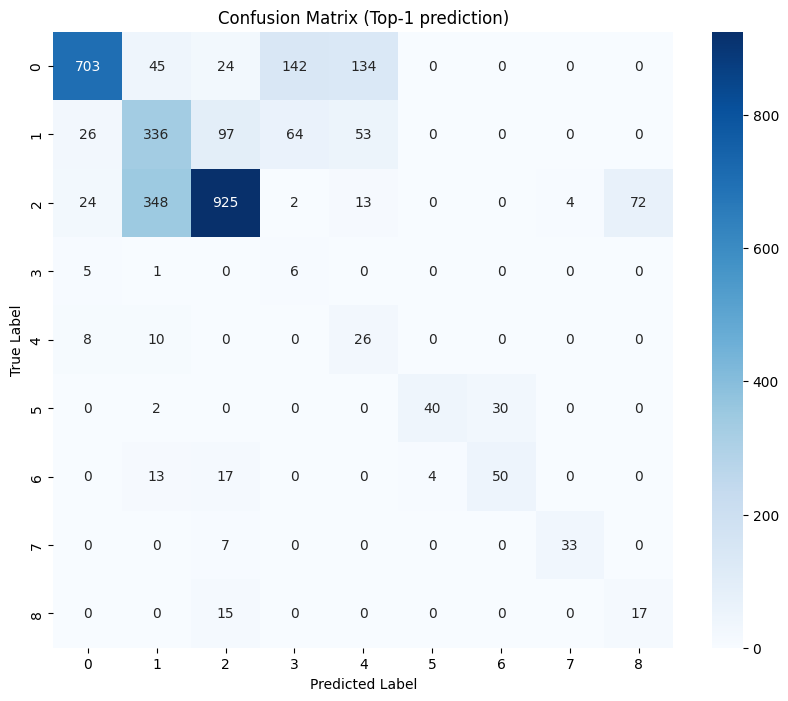

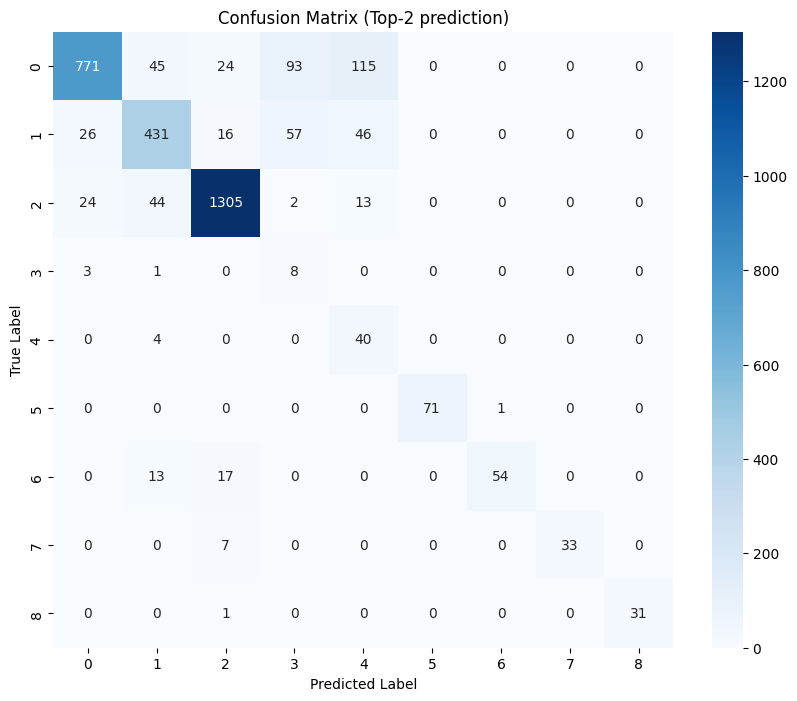

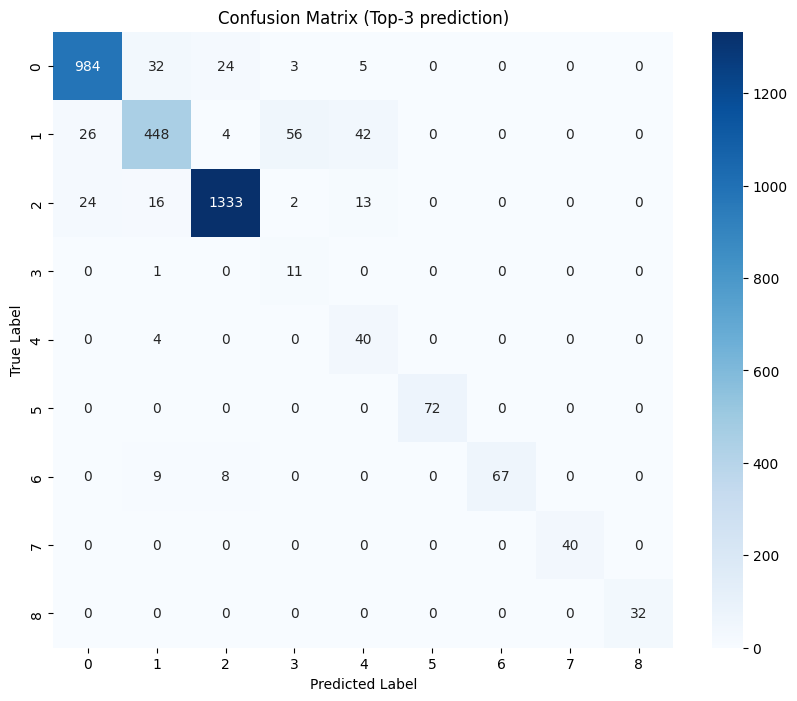

In [26]:
## using different data

import numpy as np

labels = np.array([0,1,2,3,4,5,6,7,8])
train_filepath = "my_data/standard2_no_norm/train.csv"
test_filepath  = "my_data/standard2_no_norm/test.csv"
EPS = 1e-8

train_data = np.loadtxt(train_filepath, delimiter=",", skiprows=1)
test_data  = np.loadtxt(test_filepath,  delimiter=",", skiprows=1)

train_X, train_y = train_data[:, :-1], train_data[:, -1].astype(int)
test_X,  test_y  = test_data[:, :-1],  test_data[:, -1].astype(int)

num_labels = len(labels)
num_features = train_X.shape[1]

print(f"Train samples: {len(train_X)}")
print(f"Test samples : {len(test_X)}")
print(f"Features     : {num_features}")
print(f"Labels       : {labels}")

train_medians = np.zeros((num_labels, num_features))
train_std     = np.zeros((num_labels, num_features))

for i, lbl in enumerate(labels):
    X_lbl = train_X[train_y == lbl]

    train_medians[i] = np.median(X_lbl, axis=0)
    train_std[i]     = np.std(X_lbl, axis=0, ddof=1)

# Avoid divide-by-zero
train_std[train_std < EPS] = EPS

def get_zscores(features, medians, stds):
    # features [...1344]
    # medians & stds [[...1344], ...9]
    # returns: zscores [[...1344], ...9]
    return (features - medians) / stds

def abs_zscores(zscores):
    # zscore [[...1344], ...9]
    return abs(zscores)

def get_labels_scores(zscores):
    # zscore [[...1344], ...9]
    # returns: labels_scores [...9]
    # Note: lower score is better (means closer to model)
    R = 1
    return np.sum(zscores, axis=R)

def get_pred_labels(labels_scores):
    # labels_score [...9]
    # returns: pred_labels [...9] of labels with label at spot 0 being the smallest label score, and so on
    pred_label_indices = np.argsort(labels_scores)
    pred_labels = labels[pred_label_indices]
    return pred_labels

def is_accurate(pred_labels, label, max_checks=len(labels)):
    # pred_labels [...9]
    # label int
    # max_trys int
    # check if pre_label at idx=0 matches label, if not and max_trys allows it, try again, ...
    for check in range(max_checks):
        if pred_labels[check] == label: return True, check
    return False, max_checks
    
all_pred_labels = []
accuracy_struct = []
for i in range(len(test_y)):
    zscores = get_zscores(test_X[i], train_medians, train_std)
    zscores = abs_zscores(zscores)
    labels_scores = get_labels_scores(zscores)
    pred_labels = get_pred_labels(labels_scores)
    all_pred_labels.append(pred_labels)
    accuracy_struct.append(is_accurate(pred_labels, test_y[i]))
    if i % 10 == 0: print(f"{i} Pred: {pred_labels}, Label: {test_y[i]}, {is_accurate(pred_labels, test_y[i])}")

# showcase the outputs for this. show a confusion matrix with all (True, 0) and show a confusion matrix with all (True,0) and (True, 1) 

acc_totals = [0, 0, 0, 0, 0, 0, 0, 0, 0]
for acc in accuracy_struct:
    is_acc, order = acc
    if is_acc: acc_totals[order] +=1

print(np.array(acc_totals) / len(test_y) * 100) 


import matplotlib.pyplot as plt
import seaborn as sns

#I apologize

# Initialize confusion matrices
conf_mat_top1 = np.zeros((num_labels, num_labels), dtype=int)  # only top-1 prediction
conf_mat_top2 = np.zeros((num_labels, num_labels), dtype=int)  # top-1 or top-2 prediction
conf_mat_top3 = np.zeros((num_labels, num_labels), dtype=int)  # top-1, top-2, or top-3 prediction

for i, (pred_labels, (is_acc, order)) in enumerate(zip(all_pred_labels, accuracy_struct)):
    true_label = test_y[i]
    true_idx = np.where(labels == true_label)[0][0]

    pred_label_top1 = pred_labels[0]
    pred_idx_top1 = np.where(labels == pred_label_top1)[0][0]
    conf_mat_top1[true_idx, pred_idx_top1] += 1

    # Top-2 confusion matrix
    if is_acc and order <= 1:
        pred_label_top2 = pred_labels[order]
        pred_idx_top2 = np.where(labels == pred_label_top2)[0][0]
        conf_mat_top2[true_idx, pred_idx_top2] += 1
    else:
        conf_mat_top2[true_idx, pred_idx_top1] += 1

    # Top-3 confusion matrix
    if is_acc and order <= 2:
        pred_label_top3 = pred_labels[order]
        pred_idx_top3 = np.where(labels == pred_label_top3)[0][0]
        conf_mat_top3[true_idx, pred_idx_top3] += 1
    else:
        conf_mat_top3[true_idx, pred_idx_top1] += 1


# Plot confusion matrices nicely
def plot_confusion_matrix(conf_mat, title):
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_mat, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(title)
    plt.show()

plot_confusion_matrix(conf_mat_top1, "Confusion Matrix (Top-1 prediction)")
plot_confusion_matrix(conf_mat_top2, "Confusion Matrix (Top-2 prediction)")
plot_confusion_matrix(conf_mat_top3, "Confusion Matrix (Top-3 prediction)")

In [ ]:
#figure out which features have the most impact using train subset. pass train back into train
#turn off one feature at a time and then save the accuarayc. 

# measure the impact of turnin each feature off has on the accuracuy when evaluating train/test

import numpy as np

labels = np.array([0,1,2,3,4,5,6,7,8])
train_filepath = "my_data/standard2/train.csv"
test_filepath  = "my_data/standard2/test.csv"
EPS = 1e-8

train_data = np.loadtxt(train_filepath, delimiter=",", skiprows=1)
test_data  = np.loadtxt(test_filepath,  delimiter=",", skiprows=1)

train_X, train_y = train_data[:, :-1], train_data[:, -1].astype(int)

num_labels = len(labels)
num_features = train_X.shape[1]

print(f"Train samples: {len(train_X)}")
print(f"Features     : {num_features}")
print(f"Labels       : {labels}")

train_medians = np.zeros((num_labels, num_features))
train_std     = np.zeros((num_labels, num_features))

for i, lbl in enumerate(labels):
    X_lbl = train_X[train_y == lbl]

    train_medians[i] = np.median(X_lbl, axis=0)
    train_std[i]     = np.std(X_lbl, axis=0, ddof=1)

# Avoid divide-by-zero
train_std[train_std < EPS] = EPS

def get_zscores(features, medians, stds):
    # features [...1344]
    # medians & stds [[...1344], ...9]
    # returns: zscores [[...1344], ...9]
    return (features - medians) / stds

def abs_zscores(zscores):
    # zscore [[...1344], ...9]
    return abs(zscores)

def get_labels_scores(zscores):
    # zscore [[...1344], ...9]
    # returns: labels_scores [...9]
    # Note: lower score is better (means closer to model)
    R = 1
    return np.sum(zscores, axis=R)

def get_pred_labels(labels_scores):
    # labels_score [...9]
    # returns: pred_labels [...9] of labels with label at spot 0 being the smallest label score, and so on
    pred_label_indices = np.argsort(labels_scores)
    pred_labels = labels[pred_label_indices]
    return pred_labels

def is_accurate(pred_labels, label, max_checks=len(labels)):
    # pred_labels [...9]
    # label int
    # max_trys int
    # check if pre_label at idx=0 matches label, if not and max_trys allows it, try again, ...
    for check in range(max_checks):
        if pred_labels[check] == label: return True, check
    return False, max_checks



def evaluate(disable_feature_idx=None):
    i = 0
    accuracy_struct = []
    for X,y in zip(train_X, train_y):
        if disable_feature_idx is not None: X[disable_feature_idx] = X[disable_feature_idx] * 0
        zscores = get_zscores(X, train_medians, train_std)
        zscores = abs_zscores(zscores)
        labels_scores = get_labels_scores(zscores)
        pred_labels = get_pred_labels(labels_scores)
        accuracy_struct.append(is_accurate(pred_labels, y))
        print(f"{disable_feature_idx} --- {i}/{len(train_X)-1}", end="\r"); i+=1
    print()
    acc_totals = [0, 0, 0, 0, 0, 0, 0, 0, 0]
    for acc in accuracy_struct:
        is_acc, order = acc
        if is_acc: acc_totals[order] +=1


    #### AGHHHHHHHHHHHH ADD / num
    return np.array(acc_totals) / len(train_X)

all_acc_totals = []
for disable_feature_idx in range(num_features):
    all_acc_totals.append(evaluate(disable_feature_idx))
    


    








Train samples: 12915
Features     : 1536
Labels       : [0 1 2 3 4 5 6 7 8]
0 --- 12914/12914
1 --- 12914/12914
2 --- 12914/12914
3 --- 12914/12914
4 --- 12914/12914
5 --- 12914/12914
6 --- 12914/12914
7 --- 12914/12914
8 --- 12914/12914
9 --- 12914/12914
10 --- 12914/12914
11 --- 12914/12914
12 --- 12914/12914
13 --- 12914/12914
14 --- 12914/12914
15 --- 12914/12914
16 --- 12914/12914
17 --- 12914/12914
18 --- 12914/12914
19 --- 12914/12914
20 --- 12914/12914
21 --- 12914/12914
22 --- 12914/12914
23 --- 12914/12914
24 --- 12914/12914
25 --- 12914/12914
26 --- 12914/12914
27 --- 12914/12914
28 --- 12914/12914
29 --- 12914/12914
30 --- 12914/12914
31 --- 12914/12914
32 --- 12914/12914
33 --- 12914/12914
34 --- 12914/12914
35 --- 12914/12914
36 --- 12914/12914
37 --- 12914/12914
38 --- 12914/12914
39 --- 12914/12914
40 --- 12914/12914
41 --- 12914/12914
42 --- 12914/12914
43 --- 12914/12914
44 --- 12914/12914
45 --- 12914/12914
46 --- 12914/12914
47 --- 12914/12914
48 --- 12914/12914
49 

[6.57220286e+01 1.83352691e+01 7.87456446e+00 4.13472706e+00
 7.43321719e-01 7.43321719e-01 1.69570267e+00 7.43321719e-01
 7.74293457e-03]
Rank  | Top Index  | Top Value (High Precision) | Bottom Index | Bottom Value          
---------------------------------------------------------------------------------------
1     | 16         | 0.093269945765         | 1535         | 0.093269945765        
2     | 17         | 0.093269945765         | 1534         | 0.093269945765        
3     | 18         | 0.093269945765         | 1533         | 0.093269945765        
4     | 19         | 0.093269945765         | 1532         | 0.093269945765        
5     | 20         | 0.093269945765         | 1531         | 0.093269945765        
6     | 21         | 0.093269945765         | 1530         | 0.093269945765        
7     | 22         | 0.093269945765         | 1529         | 0.093269945765        
8     | 23         | 0.093269945765         | 1528         | 0.093269945765        
9     | 24   

/tmp/ipykernel_79452/2029153282.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


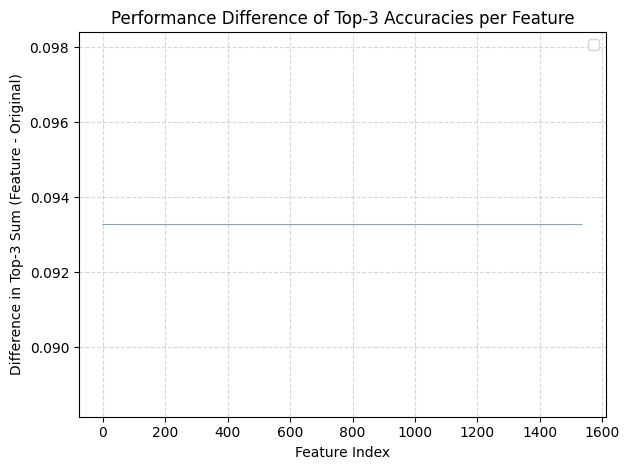

In [40]:
# 

# #all_acc_totals len of 1533 features, all_acc_totals[0] len = 9
# # compare the sum of the first 3 accuracies in orig_acc to the sum of first 3 accuraciies in each feature. plot this value as y and feature idx as x
# print(len(all_acc_totals))
import numpy as np
import matplotlib.pyplot as plt

# Original baseline accuracies
orig_acc = np.array([64.80582524, 18.44660194, 8.58616505, 4.21723301, 0.84951456, 
                     0.97087379, 1.39563107, 0.72815534, 0])

# Pre-calculating the sum of the first 3 original accuracies
orig_top3_sum = np.sum(orig_acc[:3])

# Assuming all_acc_totals is a numpy array of shape (1533, 9)
# If it is a list of lists, convert it first: all_acc_totals = np.array(all_acc_totals)

# Calculation:
# Subtract orig_acc from each feature, then sum the first 3 elements
# This is equivalent to (sum of first 3 of feature) - (sum of first 3 of orig)
y_values = np.sum(all_acc_totals[:, :3]/12915 * 100 - orig_acc[:3], axis=1)
x_values = np.arange(len(all_acc_totals))

# Visualization
plt.plot(x_values, y_values, color='steelblue', alpha=0.7, linewidth=0.8)
plt.xlabel('Feature Index')
plt.ylabel('Difference in Top-3 Sum (Feature - Original)')
plt.title('Performance Difference of Top-3 Accuracies per Feature')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

print(np.array(all_acc_totals[0]) / 12915 * 100)

import numpy as np

# 1. Calculation (using your logic)
# Ensure all_acc_totals is a numpy array
all_acc_totals_arr = np.array(all_acc_totals) 
y_values = np.sum(all_acc_totals_arr[:, :3] / 12915 * 100 - orig_acc[:3], axis=1)

# 2. Get indices for sorting
sorted_indices = np.argsort(y_values)

# 100 Greatest (Largest first)
top_100_idx = sorted_indices[-100:][::-1]
top_100_vals = y_values[top_100_idx]

# 100 Smallest (Smallest first)
bottom_100_idx = sorted_indices[:100]
bottom_100_vals = y_values[bottom_100_idx]

# 3. Print the Table with high precision (.12f)
header = f"{'Rank':<5} | {'Top Index':<10} | {'Top Value (High Precision)':<22} | {'Bottom Index':<12} | {'Bottom Value':<22}"
print(header)
print("-" * len(header))

for i in range(100):
    print(f"{i+1:<5} | {top_100_idx[i]:<10} | {top_100_vals[i]:<22.12f} | {bottom_100_idx[i]:<12} | {bottom_100_vals[i]:<22.12f}")

# Optional: Export to CSV for full inspection
# import pandas as pd
# results_df = pd.DataFrame({
#     'Rank': range(1, 101),
#     'Top_Idx': top_100_idx,
#     'Top_Val': top_100_vals,
#     'Bottom_Idx': bottom_100_idx,
#     'Bottom_Val': bottom_100_vals
# })
# results_df.to_csv('feature_analysis_extremes.csv', index=False)


# # all_acc_totals: shape [num_features, 9]
# all_acc_totals = np.array(all_acc_totals)

# top3_per_feature = np.sum(all_acc_totals[:, :3], axis=1)

# plt.figure(figsize=(12, 5))
# plt.plot(top3_per_feature, linewidth=1, label="Feature Top-3 Accuracy")

# # Baseline reference line
# plt.axhline(orig_top3, linestyle="--", linewidth=2, label="Original Top-3 Accuracy")

# plt.xlabel("Feature Index")
# plt.ylabel("Top-3 Accuracy (%)")
# plt.title("Top-3 Accuracy vs Feature Index")
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()

# best_idx = np.argsort(top3_per_feature)[::-1][:10]
# for i in best_idx:
#     print(f"Feature {i:4d} | Top-3 Acc = {top3_per_feature[i]:.2f}%")
